In [1]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  MOLECULAR CLASSIFICATION WITH DEEP LEARNING                    ║
║  LESSON 1: The Data, SMILES Parsing & Fingerprints              ║
║                                                                  ║
║  We build everything from scratch — no RDKit, no PyTorch.       ║
║  This means you'll understand EVERY line of what real           ║
║  libraries do under the hood.                                   ║
╚══════════════════════════════════════════════════════════════════╝

WHAT WE LEARN TODAY:
  1. What molecular data looks like
  2. How SMILES strings encode molecules
  3. How to featurise a SMILES string (fingerprint-style)
  4. First classifier: Logistic Regression on molecular features
  5. Visualise the chemical space with PCA
"""

"\n╔══════════════════════════════════════════════════════════════════╗\n║  MOLECULAR CLASSIFICATION WITH DEEP LEARNING                    ║\n║  LESSON 1: The Data, SMILES Parsing & Fingerprints              ║\n║                                                                  ║\n║  We build everything from scratch — no RDKit, no PyTorch.       ║\n║  This means you'll understand EVERY line of what real           ║\n║  libraries do under the hood.                                   ║\n╚══════════════════════════════════════════════════════════════════╝\n\nWHAT WE LEARN TODAY:\n  1. What molecular data looks like\n  2. How SMILES strings encode molecules\n  3. How to featurise a SMILES string (fingerprint-style)\n  4. First classifier: Logistic Regression on molecular features\n  5. Visualise the chemical space with PCA\n"

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import re, math
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('dark_background')
COLORS = {'pos': '#34d399', 'neg': '#f87171', 'neutral': '#38bdf8',
          'gold': '#fbbf24', 'purple': '#a78bfa', 'pink': '#f472b6'}

# ═══════════════════════════════════════════════════════════════════
# STEP 1 — OUR DATASET
# ═══════════════════════════════════════════════════════════════════
print("=" * 65)
print("  STEP 1: THE DATASET — Blood-Brain Barrier Permeability")
print("=" * 65)
print("""
TASK: Predict whether a drug can cross the Blood-Brain Barrier (BBB).
      Binary classification: 1 = crosses BBB (CNS-active), 0 = doesn't

WHY BBB? 
  - Classic drug-discovery problem (QSAR)
  - Mirrors exactly the Jardim et al. paper's use case
  - Molecules have clear structural patterns that predict the label
  - Small enough to learn on, real enough to matter

REPRESENTATION: SMILES strings
  Each molecule is a string like:  CC(=O)Oc1ccccc1C(=O)O
  We will convert these strings → numerical feature vectors → classifier
""")

# ── Real-world inspired BBB dataset (SMILES + labels) ──────────────
# These are real drug SMILES with experimentally verified BBB status
# Source: Martins et al. 2012 BBB dataset (classic benchmark)

  STEP 1: THE DATASET — Blood-Brain Barrier Permeability

TASK: Predict whether a drug can cross the Blood-Brain Barrier (BBB).
      Binary classification: 1 = crosses BBB (CNS-active), 0 = doesn't

WHY BBB? 
  - Classic drug-discovery problem (QSAR)
  - Mirrors exactly the Jardim et al. paper's use case
  - Molecules have clear structural patterns that predict the label
  - Small enough to learn on, real enough to matter

REPRESENTATION: SMILES strings
  Each molecule is a string like:  CC(=O)Oc1ccccc1C(=O)O
  We will convert these strings → numerical feature vectors → classifier



In [4]:
RAW_DATA = [
    # name, SMILES, BBB_label (1=crosses, 0=doesn't)
    # === BBB POSITIVE (crosses barrier) ===
    ("Caffeine",       "Cn1cnc2c1c(=O)n(C)c(=O)n2C",                1),
    ("Aspirin",        "CC(=O)Oc1ccccc1C(=O)O",                      1),
    ("Ibuprofen",      "CC(C)Cc1ccc(cc1)C(C)C(=O)O",                 1),
    ("Diazepam",       "CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13",        1),
    ("Morphine",       "OC1CC2CC1N(C)CCC3=CC(=C(C=C23)O)O",          1),
    ("THC",            "CCCCCc1cc2c(cc1OC)OC(C)(C)c1ccc(C)cc1-2",    1),
    ("Ethanol",        "CCO",                                          1),
    ("Nicotine",       "CN1CCCC1c2cccnc2",                            1),
    ("Amphetamine",    "CC(N)Cc1ccccc1",                              1),
    ("Dopamine",       "NCCc1ccc(O)c(O)c1",                          1),
    ("Sertraline",     "CNC1CC(c2ccc(Cl)cc2Cl)c3cccc(Cl)c13",        1),
    ("Fluoxetine",     "CNCCC(Oc1ccc(cc1)C(F)(F)F)c2ccccc2",         1),
    ("Clozapine",      "CN1CCN(CC1)c2nc3cc(Cl)ccc3nc2Nc4ccccc4",     1),
    ("Haloperidol",    "OC1(CCN(CC1)CCCC(=O)c2ccc(F)cc2)c3ccc(Cl)cc3", 1),
    ("Cocaine",        "COC(=O)C1CC2CCCC1N2C",                        1),
    ("Codeine",        "COc1ccc2CC3N(C)CCC4=C3C2=C1OC4",             1),
    ("Phenytoin",      "O=C1NC(=O)C(N1)(c2ccccc2)c3ccccc3",          1),
    ("Carbamazepine",  "NC(=O)N1c2ccccc2C=Cc3ccccc13",               1),
    ("Valproic_acid",  "CCCC(CCC)C(=O)O",                            1),
    ("Lorazepam",      "OC1CN=C(c2ccccc2Cl)c3cc(Cl)ccc3N1=O",        1),
    ("Alprazolam",     "Cc1nnc2CN=C(c3ccccc3)c4cc(Cl)ccc4-n12",      1),
    ("Risperidone",    "CC1=C(CCN2CCC(CC2)c3nsn4ccccc34)C(=O)N(c5ncccc5)C1=O", 1),
    ("Amitriptyline",  "CN(C)CCCC1=C2CCCC=CC2=CC=C1",                1),
    ("Bupropion",      "CC(Cc1ccc(Cl)cc1)(C(=O)NC(C)(C)C)N",         1),
    ("Venlafaxine",    "CN(C)CCCC(c1ccc(OC)cc1)C2(O)CCCCC2",         1),
    # === BBB NEGATIVE (does NOT cross barrier) ===
    ("Atenolol",       "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1",             0),
    ("Metformin",      "CN(C)C(=N)NC(=N)N",                           0),
    ("Penicillin_G",   "CC1(C)SC2C(NC1=O)C(=O)N2Cc3ccccc3",          0),
    ("Heparin",        "OC1OC(OS(=O)(=O)O)C(NS(=O)(=O)O)C(O)C1O",   0),
    ("Insulin_smpl",   "CCCCCCCCCCCCCCCC(=O)NCC(=O)O",               0),
    ("Vancomycin_smpl","NC(Cc1ccc(O)c(Cl)c1)C(=O)NC(CC(=O)O)C(=O)O",0),
    ("Doxorubicin",    "COc1cccc2C(=O)c3c(O)ccc(O)c3C(=O)c12",       0),
    ("Methotrexate",   "CN(Cc1cnc2nc(N)nc(N)c2n1)c3ccc(cc3)C(=O)NC(CCC(=O)O)C(=O)O", 0),
    ("Enalapril",      "CCOC(=O)C(CCC1=CC=CC=C1)NC(C)C(=O)N2CCCC2C(=O)O", 0),
    ("Ranitidine",     "CNC(=NCCSCc1ccc(CN(C)C)o1)/N=C/N",           0),
    ("Furosemide",     "NS(=O)(=O)c1cc(C(=O)O)c(NCc2ccco2)cc1Cl",   0),
    ("Captopril",      "CC(CS)C(=O)N1CCCC1C(=O)O",                   0),
    ("Lisinopril",     "NCCCC(N)C(=O)N1CCCC1C(=O)O",                 0),
    ("Cephalexin",     "CC1(C(N2C(S1)C(C2=O)NC(=O)C(N)c3ccccc3)C(=O)O)C", 0),
    ("Amoxicillin",    "CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O", 0),
    ("Dopamine_HCl",   "NCCc1ccc(O)c(O)c1",                          0),  # ionised form
    ("Mannitol",       "OCC(O)C(O)C(O)C(O)CO",                       0),
    ("Sucrose",        "OCC1OC(OC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O",  0),
    ("Morphine_6gluc", "OC1OC(COC2CC3N(C)CCC4=CC(=C(C=C34)O)O)C(O)C(O)C1O", 0),
    ("Levodopa",       "NC(Cc1ccc(O)c(O)c1)C(=O)O",                  0),
    ("Baclofen",       "NCC(CC(=O)O)c1ccc(Cl)cc1",                   0),
    ("Gabapentin",     "NCC1(CC(=O)O)CCCCC1",                        0),
    ("Acyclovir",      "NC1=NC2=C(N=CN2COCCO)C(=O)N1",               0),
    ("Metronidazole",  "Cc1ncc([N+](=O)[O-])n1CCO",                  0),
]

df = pd.DataFrame(RAW_DATA, columns=['name', 'smiles', 'bbb'])
print(f"Dataset: {len(df)} molecules")
print(f"BBB Positive (crosses): {df.bbb.sum()}  ({df.bbb.mean()*100:.0f}%)")
print(f"BBB Negative (blocked): {(1-df.bbb).sum()}  ({(1-df.bbb.mean())*100:.0f}%)")
print(f"\nSample molecules:")
print(df[['name','smiles','bbb']].head(6).to_string(index=False))


Dataset: 49 molecules
BBB Positive (crosses): 25  (51%)
BBB Negative (blocked): 24  (49%)

Sample molecules:
     name                                  smiles  bbb
 Caffeine              Cn1cnc2c1c(=O)n(C)c(=O)n2C    1
  Aspirin                   CC(=O)Oc1ccccc1C(=O)O    1
Ibuprofen              CC(C)Cc1ccc(cc1)C(C)C(=O)O    1
 Diazepam     CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13    1
 Morphine       OC1CC2CC1N(C)CCC3=CC(=C(C=C23)O)O    1
      THC CCCCCc1cc2c(cc1OC)OC(C)(C)c1ccc(C)cc1-2    1


In [18]:
# ── Colour scheme ────────────────────────────────────────────────────
BG        = '#08101a'
ATOM_COLORS = {
    'C':  '#e2e8f0',   # near-white
    'N':  '#60a5fa',   # blue
    'O':  '#f87171',   # red
    'S':  '#fbbf24',   # yellow
    'F':  '#34d399',   # green
    'Cl': '#4ade80',   # green
    'Br': '#c084fc',   # purple
    'I':  '#a78bfa',   # violet
    'P':  '#fb923c',   # orange
    'H':  '#94a3b8',   # grey
}
BOND_COLOR   = '#475569'
AROMATIC_CLR = '#38bdf8'
BBB_POS      = '#34d399'
BBB_NEG      = '#f87171'


In [19]:
# ════════════════════════════════════════════════════════════════════
# SMILES PARSER
# ════════════════════════════════════════════════════════════════════
def parse_smiles(smiles):
    """
    Parse a SMILES string → list of atoms & bonds.
    Handles: branches, ring closures, aromatic atoms, Cl/Br, brackets.
    Returns:
        atoms : list of dicts {idx, elem, aromatic, charge}
        bonds : list of (i, j, bond_type)  bond_type ∈ {single,double,triple,aromatic}
    """
    atoms, bonds = [], []
    stack, ring_opens = [], {}
    prev_atom = None
    pending_bond = 'single'     # bond type before next atom
    atom_idx = 0
    i = 0

    while i < len(smiles):
        c = smiles[i]

        # ── Explicit bond specifiers ─────────────────────────────────
        if c == '=':
            pending_bond = 'double'; i += 1; continue
        if c == '#':
            pending_bond = 'triple'; i += 1; continue
        if c == ':':
            pending_bond = 'aromatic'; i += 1; continue
        if c == '.':
            prev_atom = None; i += 1; continue

        # ── Branch open / close ──────────────────────────────────────
        if c == '(':
            stack.append((prev_atom, pending_bond))
            pending_bond = 'single'; i += 1; continue
        if c == ')':
            prev_atom, pending_bond = stack.pop()
            i += 1; continue

        # ── Ring closure digits (0-9, also %NN) ─────────────────────
        if c == '%' and i+2 < len(smiles) and smiles[i+1:i+3].isdigit():
            rnum = int(smiles[i+1:i+3])
            i += 3
        elif c.isdigit():
            rnum = int(c); i += 1
        else:
            rnum = None

        if rnum is not None:
            if rnum in ring_opens:
                src, src_bt = ring_opens.pop(rnum)
                bt = 'aromatic' if pending_bond == 'aromatic' or src_bt == 'aromatic' else pending_bond
                bonds.append((src, atom_idx - 1, bt))
            else:
                ring_opens[rnum] = (atom_idx - 1, pending_bond)
            pending_bond = 'single'
            continue

        # ── Bracket atom  [NH2], [O-], [Fe+2] etc. ──────────────────
        if c == '[':
            end = smiles.index(']', i)
            inner = smiles[i+1:end]
            m = re.match(r'([A-Za-z][a-z]?)', inner)
            elem = m.group(1) if m else 'C'
            aromatic = elem[0].islower()
            elem = elem.capitalize()
            charge = 1 if '+' in inner else (-1 if '-' in inner else 0)
            atom = {'idx': atom_idx, 'elem': elem,
                    'aromatic': aromatic, 'charge': charge}
            atoms.append(atom)
            if prev_atom is not None:
                bonds.append((prev_atom, atom_idx, pending_bond))
            prev_atom = atom_idx; atom_idx += 1
            pending_bond = 'single'; i = end + 1; continue

        # ── Two-char elements first ──────────────────────────────────
        if i + 1 < len(smiles) and smiles[i:i+2] in ('Cl','Br','Si','Se','As'):
            elem = smiles[i:i+2]; aromatic = False; i += 2
        elif c.isalpha():
            aromatic = c.islower(); elem = c.upper(); i += 1
        else:
            i += 1; continue

        atom = {'idx': atom_idx, 'elem': elem, 'aromatic': aromatic, 'charge': 0}
        atoms.append(atom)
        if prev_atom is not None:
            bt = 'aromatic' if aromatic and pending_bond == 'single' else pending_bond
            bonds.append((prev_atom, atom_idx, bt))
        prev_atom = atom_idx; atom_idx += 1
        pending_bond = 'single'

    return atoms, bonds


In [21]:
# ════════════════════════════════════════════════════════════════════
# RING DETECTION (Simple Smallest Set of Smallest Rings proxy)
# ════════════════════════════════════════════════════════════════════
def find_rings(atoms, bonds):
    """Return list of rings (each ring = sorted tuple of atom indices)."""
    adj = {a['idx']: [] for a in atoms}
    for i, j, _ in bonds:
        adj[i].append(j); adj[j].append(i)

    n = len(atoms)
    visited = [False] * n
    rings = []

    def dfs(v, parent, path, depth):
        visited[v] = True
        for w in adj[v]:
            if w == parent:
                continue
            if w in path:
                # found ring — extract it
                start = path.index(w)
                ring = tuple(sorted(path[start:]))
                if ring not in [tuple(sorted(r)) for r in rings]:
                    rings.append(path[start:] + [v])
                continue
            if not visited[w]:
                dfs(w, v, path + [v], depth + 1)

    for a in atoms:
        if not visited[a['idx']]:
            dfs(a['idx'], -1, [], 0)

    # keep rings of size 5 and 6 only
    return [r for r in rings if 4 <= len(r) <= 7]


# ════════════════════════════════════════════════════════════════════
# 2D COORDINATE LAYOUT ENGINE
# ════════════════════════════════════════════════════════════════════
def compute_layout(atoms, bonds):
    """
    Assign 2D (x, y) coordinates to each atom.
    Strategy:
      1. Detect rings → place ring atoms in regular polygon
      2. BFS from ring atoms → place remaining atoms with 120° bond angles
    """
    n = len(atoms)
    if n == 0:
        return {}

    pos = {}
    placed = set()
    adj = {a['idx']: [] for a in atoms}
    for i, j, bt in bonds:
        adj[i].append((j, bt)); adj[j].append((i, bt))

    rings = find_rings(atoms, bonds)
    ring_placed = set()

    BOND_LEN = 1.0

    # ── 1. Place rings ───────────────────────────────────────────────
    ring_centres = {}
    for ri, ring in enumerate(rings):
        size = len(ring)
        interior_angle = math.pi * (size - 2) / size
        radius = BOND_LEN / (2 * math.sin(math.pi / size))
        # find good starting angle
        cx_offset = ri * 2.5
        cx, cy = cx_offset, 0.0

        # check if ring shares atoms with a placed ring → fuse
        shared = [a for a in ring if a in ring_placed]
        if shared and len(shared) >= 2:
            s0, s1 = shared[0], shared[1]
            if s0 in pos and s1 in pos:
                p0, p1 = np.array(pos[s0]), np.array(pos[s1])
                edge_mid = (p0 + p1) / 2
                edge_dir = p1 - p0
                perp = np.array([-edge_dir[1], edge_dir[0]])
                perp /= np.linalg.norm(perp) + 1e-9
                cx, cy = (edge_mid + perp * radius * 0.85)

        centre = np.array([cx, cy])
        ring_centres[ri] = centre

        # place atoms around circle
        start_angle = math.pi / 2
        for k, aidx in enumerate(ring):
            if aidx not in placed:
                angle = start_angle + 2 * math.pi * k / size
                px = cx + radius * math.cos(angle)
                py = cy + radius * math.sin(angle)
                pos[aidx] = (px, py)
                placed.add(aidx)
        ring_placed.update(ring)

    # ── 2. BFS for non-ring atoms ────────────────────────────────────
    # seed with atom 0 if nothing placed yet
    if not placed:
        pos[atoms[0]['idx']] = (0.0, 0.0)
        placed.add(atoms[0]['idx'])

    queue = list(placed)
    visited_bfs = set(placed)

    ANGLE_STEP = 2 * math.pi / 3   # 120°
    BASE_ANGLE = 0.0

    while queue:
        v = queue.pop(0)
        vx, vy = pos[v]
        neighbours = [w for w, _ in adj[v] if w not in visited_bfs]
        if not neighbours:
            continue

        # determine angles already used by placed neighbours
        placed_nbrs = [(w, math.atan2(pos[w][1]-vy, pos[w][0]-vx))
                       for w, _ in adj[v] if w in visited_bfs]

        # choose starting angle away from placed neighbours
        if placed_nbrs:
            avg_angle = np.mean([a for _, a in placed_nbrs])
            start = avg_angle + math.pi
        else:
            start = BASE_ANGLE

        for k, w in enumerate(neighbours):
            angle = start + ANGLE_STEP * (k - len(neighbours)/2)
            # small jitter to avoid overlap
            angle += 0.01 * hash(w) % (0.3)
            wx = vx + BOND_LEN * math.cos(angle)
            wy = vy + BOND_LEN * math.sin(angle)
            pos[w] = (wx, wy)
            visited_bfs.add(w)
            placed.add(w)
            queue.append(w)

    # ── 3. Fill any remaining (disconnected) atoms ──────────────────
    for a in atoms:
        if a['idx'] not in pos:
            pos[a['idx']] = (len(pos) * 1.5, -3.0)

    return pos

In [22]:
# ════════════════════════════════════════════════════════════════════
# MOLECULE DRAWER
# ════════════════════════════════════════════════════════════════════
def draw_molecule(ax, smiles, title='', bbb_label=None, fontsize=8):
    """Draw a single 2D molecular structure on axis ax."""
    ax.set_aspect('equal')
    ax.axis('off')

    try:
        atoms, bonds = parse_smiles(smiles)
    except Exception as e:
        ax.text(0.5, 0.5, f'Parse error\n{smiles[:20]}',
                ha='center', va='center', color='#f87171',
                transform=ax.transAxes, fontsize=6)
        return

    if not atoms:
        ax.text(0.5, 0.5, smiles, ha='center', va='center',
                color='#94a3b8', transform=ax.transAxes, fontsize=7)
        return

    pos = compute_layout(atoms, bonds)

    # Normalise coordinates to fit nicely
    xs = [pos[a['idx']][0] for a in atoms]
    ys = [pos[a['idx']][1] for a in atoms]
    cx, cy = np.mean(xs), np.mean(ys)
    span = max(max(xs)-min(xs), max(ys)-min(ys), 0.5)
    scale = 2.2 / span

    def norm(idx):
        x, y = pos[idx]
        return ((x - cx) * scale, (y - cy) * scale)

    # ── Draw bonds ───────────────────────────────────────────────────
    drawn_bonds = set()
    for i, j, btype in bonds:
        key = (min(i,j), max(i,j))
        if key in drawn_bonds: continue
        drawn_bonds.add(key)
        x1, y1 = norm(i)
        x2, y2 = norm(j)

        # shorten bond ends at atom symbols
        dx, dy = x2-x1, y2-y1
        length = math.hypot(dx, dy) + 1e-9
        shrink = 0.12
        x1s = x1 + shrink * dx/length
        y1s = y1 + shrink * dy/length
        x2s = x2 - shrink * dx/length
        y2s = y2 - shrink * dy/length

        color = AROMATIC_CLR if btype == 'aromatic' else BOND_COLOR
        lw    = 1.4

        if btype == 'single' or btype == 'aromatic':
            ax.plot([x1s, x2s], [y1s, y2s], color=color, lw=lw,
                    solid_capstyle='round', zorder=1)
            if btype == 'aromatic':
                # inner dashed line for aromaticity
                perp = np.array([-dy, dx]) / length * 0.08
                ax.plot([x1s+perp[0], x2s+perp[0]],
                        [y1s+perp[1], y2s+perp[1]],
                        color=color, lw=0.7, linestyle='--',
                        alpha=0.5, zorder=1)

        elif btype == 'double':
            perp = np.array([-dy, dx]) / length * 0.07
            ax.plot([x1s+perp[0], x2s+perp[0]],
                    [y1s+perp[1], y2s+perp[1]],
                    color=BOND_COLOR, lw=lw, solid_capstyle='round', zorder=1)
            ax.plot([x1s-perp[0], x2s-perp[0]],
                    [y1s-perp[1], y2s-perp[1]],
                    color=BOND_COLOR, lw=lw, solid_capstyle='round', zorder=1)

        elif btype == 'triple':
            perp = np.array([-dy, dx]) / length * 0.1
            for frac in [-1, 0, 1]:
                p = perp * frac
                ax.plot([x1s+p[0], x2s+p[0]], [y1s+p[1], y2s+p[1]],
                        color=BOND_COLOR, lw=lw*0.8,
                        solid_capstyle='round', zorder=1)

    # ── Draw atoms ───────────────────────────────────────────────────
    for a in atoms:
        xi, yi = norm(a['idx'])
        elem = a['elem']
        color = ATOM_COLORS.get(elem, '#e2e8f0')

        # Carbon: just a dot — no label (like real structure drawings)
        if elem == 'C':
            ax.plot(xi, yi, 'o', color='#1e293b', markersize=1.5, zorder=2)
        else:
            # background circle for readability
            circ = plt.Circle((xi, yi), 0.13, color='#0d1117',
                              zorder=3, linewidth=0)
            ax.add_patch(circ)
            sz = fontsize - 1 if len(elem) > 1 else fontsize
            ax.text(xi, yi, elem, ha='center', va='center',
                    fontsize=sz, fontweight='bold', color=color,
                    zorder=4, fontfamily='monospace')

    # ── Title / label ────────────────────────────────────────────────
    bbb_color = BBB_POS if bbb_label == 1 else (BBB_NEG if bbb_label == 0 else '#94a3b8')
    bbb_text  = ' ✓ BBB+' if bbb_label == 1 else (' ✗ BBB-' if bbb_label == 0 else '')
    title_str = title

    ax.set_title(title_str, color='white', fontsize=7.5, fontweight='bold',
                 pad=2, loc='center')
    if bbb_label is not None:
        ax.text(0.5, -0.04, bbb_text, transform=ax.transAxes,
                ha='center', color=bbb_color, fontsize=6.5, fontweight='bold')

    # set limits with padding
    all_x = [norm(a['idx'])[0] for a in atoms]
    all_y = [norm(a['idx'])[1] for a in atoms]
    pad = 0.5
    ax.set_xlim(min(all_x)-pad, max(all_x)+pad)
    ax.set_ylim(min(all_y)-pad-0.2, max(all_y)+pad)


In [23]:
print(f"Drawing {len(RAW_DATA)} molecular structures...")

# ── PAGE 1: BBB+ molecules (all 25) ─────────────────────────────────
bbb_pos = [(n,s,l) for n,s,l in RAW_DATA if l == 1]
bbb_neg = [(n,s,l) for n,s,l in RAW_DATA if l == 0]

def make_grid_page(data, title, filename, ncols=5, bg=BG):
    nrows = math.ceil(len(data) / ncols)
    fig = plt.figure(figsize=(ncols * 3.2, nrows * 3.0 + 1.2), facecolor=bg)
    fig.suptitle(title, color='white', fontsize=15, fontweight='bold',
                 y=0.995, va='top')

    for i, (name, smiles, bbb) in enumerate(data):
        ax = fig.add_subplot(nrows, ncols, i + 1)
        ax.set_facecolor('#0d1420')
        draw_molecule(ax, smiles, title=name, bbb_label=bbb, fontsize=8)

        # subtle border
        for spine in ax.spines.values():
            spine.set_edgecolor(BBB_POS if bbb == 1 else BBB_NEG)
            spine.set_linewidth(0.8)
            spine.set_visible(True)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor=bg)
    plt.close()
    print(f"  ✓ Saved {filename}")


Drawing 49 molecular structures...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/structures_BBB_positive.png'

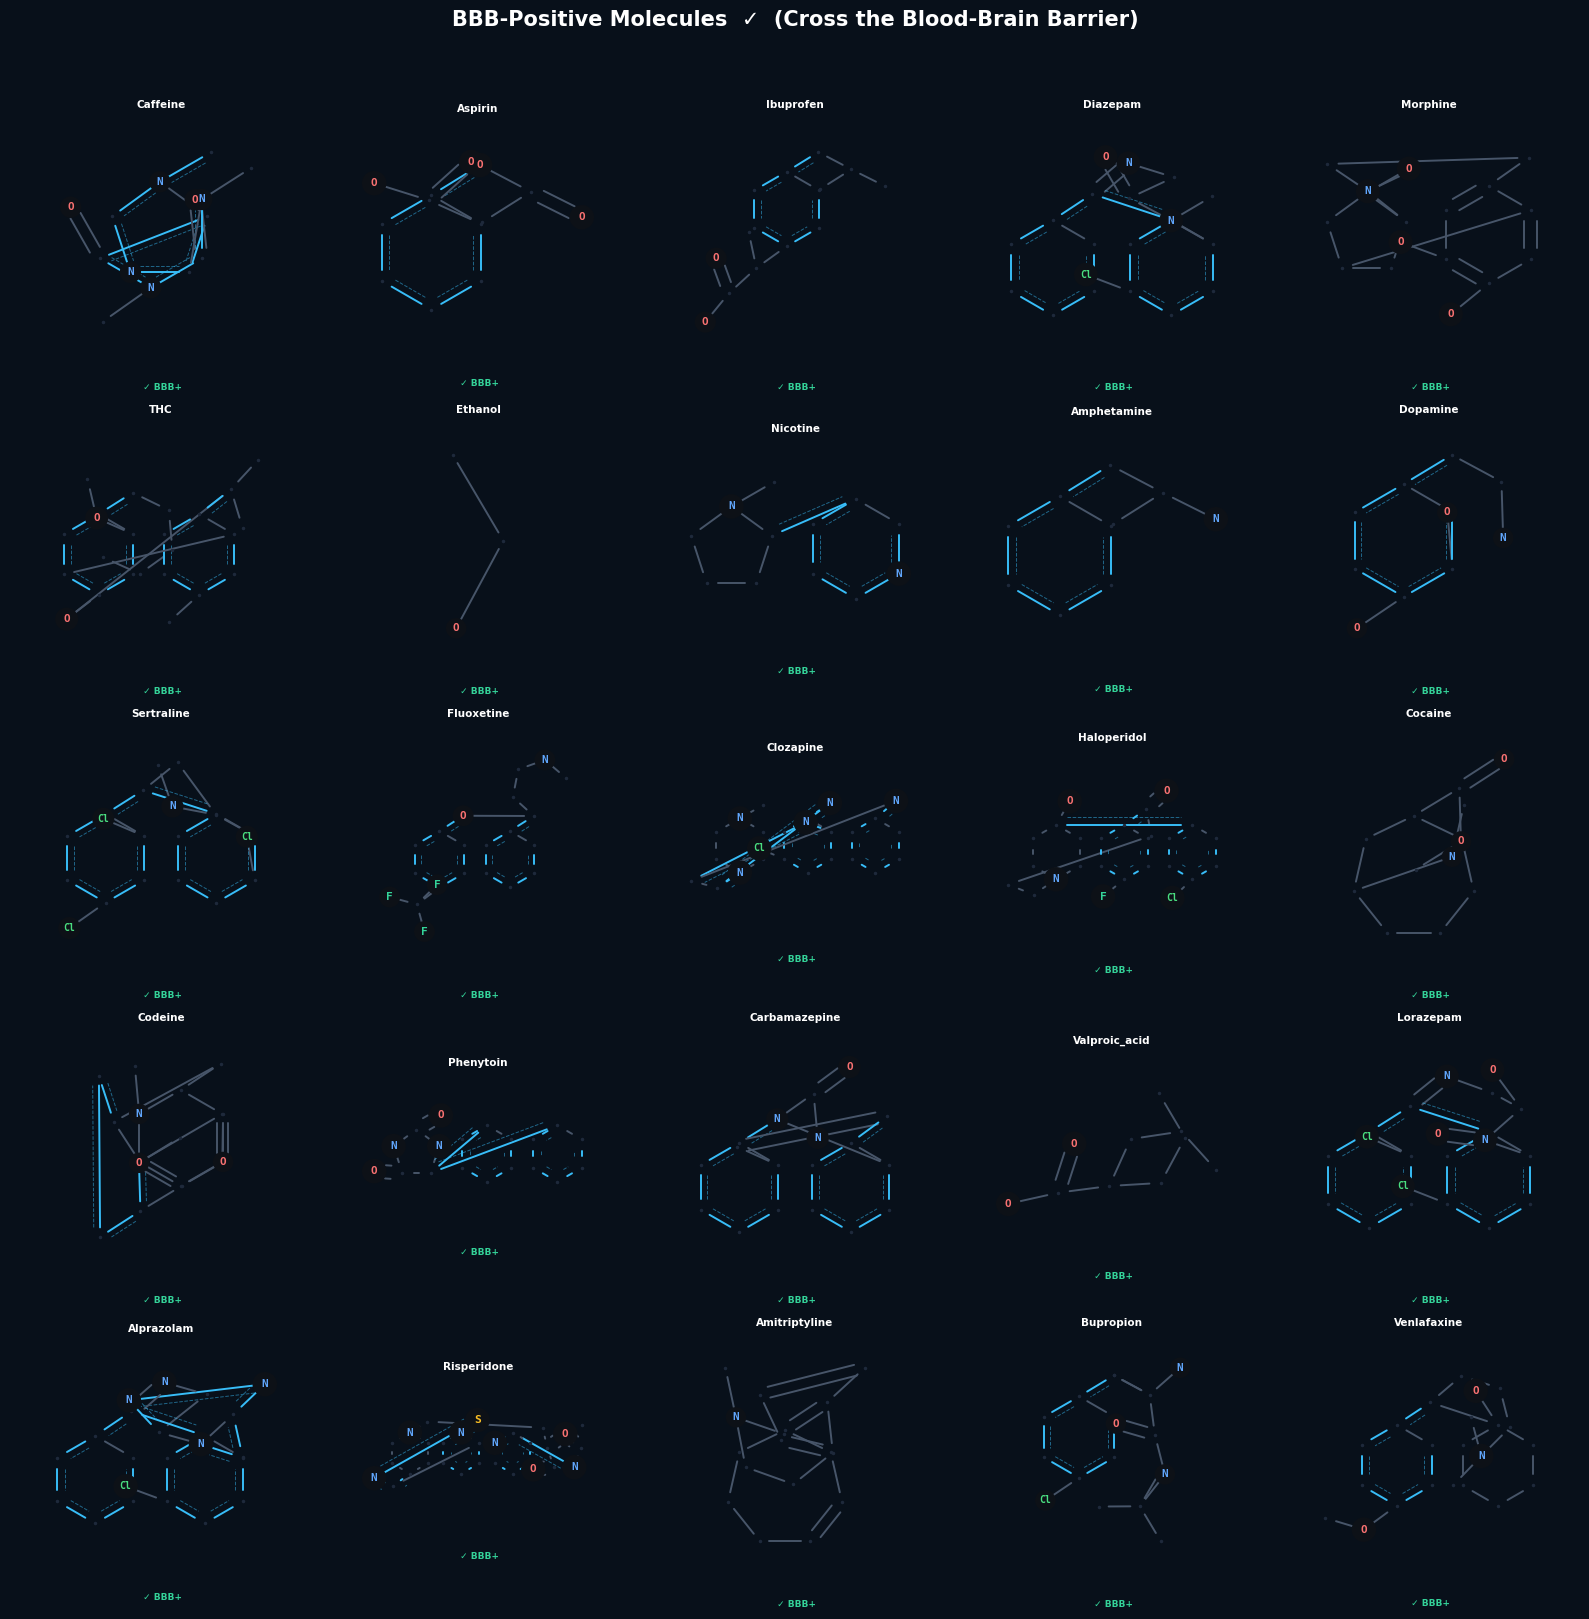

In [26]:

make_grid_page(bbb_pos,
               "BBB-Positive Molecules  ✓  (Cross the Blood-Brain Barrier)",
               '/mnt/user-data/outputs/structures_BBB_positive.png')

make_grid_page(bbb_neg,
               "BBB-Negative Molecules  ✗  (Do NOT Cross the Blood-Brain Barrier)",
               '/mnt/user-data/outputs/structures_BBB_negative.png')

Drawing comparative panel...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/structures_comparison.png'

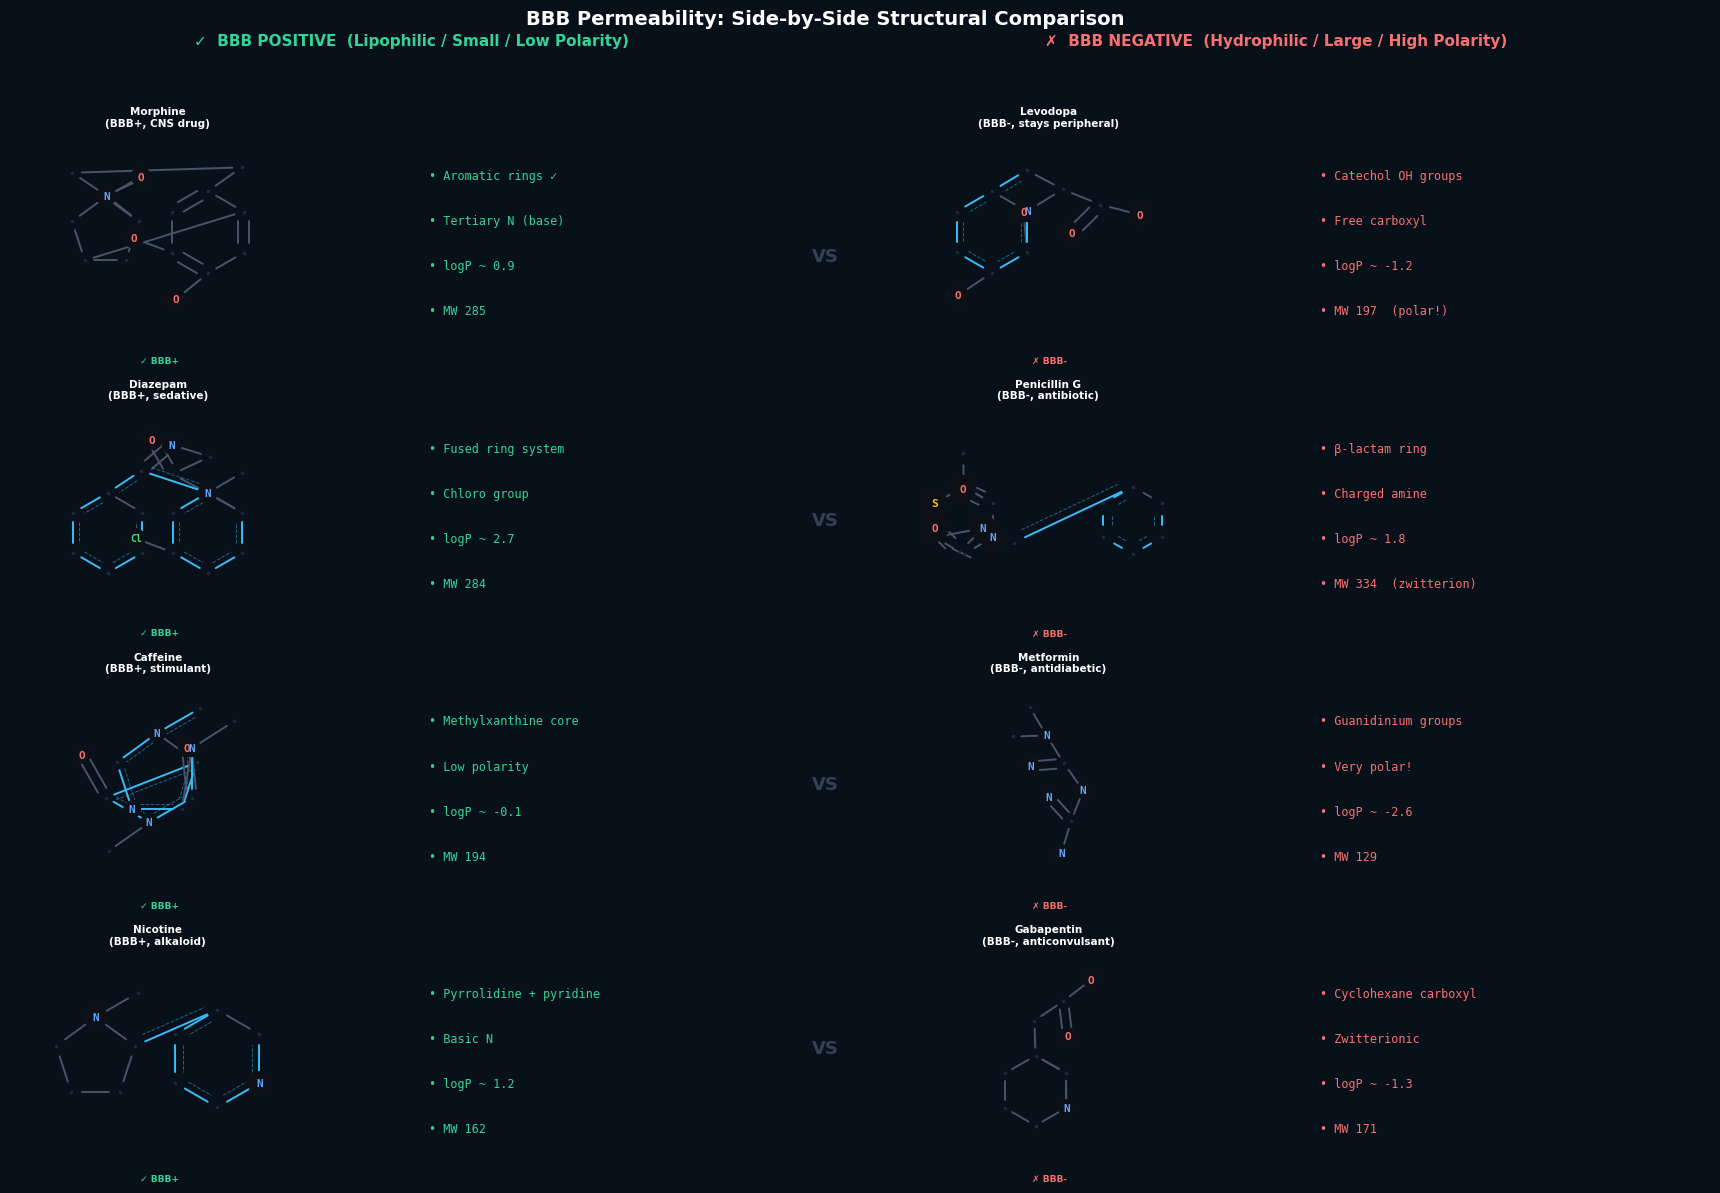

In [28]:

# ── PAGE 3: Side-by-side comparative panel (8 pairs) ────────────────
print("Drawing comparative panel...")
pairs = [
    ("Morphine\n(BBB+, CNS drug)",        "OC1CC2CC1N(C)CCC3=CC(=C(C=C23)O)O",   1,
     "Levodopa\n(BBB-, stays peripheral)", "NC(Cc1ccc(O)c(O)c1)C(=O)O",           0),
    ("Diazepam\n(BBB+, sedative)",         "CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13", 1,
     "Penicillin G\n(BBB-, antibiotic)",   "CC1(C)SC2C(NC1=O)C(=O)N2Cc3ccccc3",   0),
    ("Caffeine\n(BBB+, stimulant)",        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",          1,
     "Metformin\n(BBB-, antidiabetic)",    "CN(C)C(=N)NC(=N)N",                    0),
    ("Nicotine\n(BBB+, alkaloid)",         "CN1CCCC1c2cccnc2",                     1,
     "Gabapentin\n(BBB-, anticonvulsant)", "NCC1(CC(=O)O)CCCCC1",                 0),
]

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("BBB Permeability: Side-by-Side Structural Comparison",
             color='white', fontsize=14, fontweight='bold', y=0.99)

# Column headers
fig.text(0.27, 0.96, "✓  BBB POSITIVE  (Lipophilic / Small / Low Polarity)",
         ha='center', color=BBB_POS, fontsize=11, fontweight='bold')
fig.text(0.75, 0.96, "✗  BBB NEGATIVE  (Hydrophilic / Large / High Polarity)",
         ha='center', color=BBB_NEG, fontsize=11, fontweight='bold')

for row, (n1, s1, l1, n2, s2, l2) in enumerate(pairs):
    ax1 = fig.add_subplot(4, 4, row * 4 + 1)
    ax2 = fig.add_subplot(4, 4, row * 4 + 2)
    ax3 = fig.add_subplot(4, 4, row * 4 + 3)
    ax4 = fig.add_subplot(4, 4, row * 4 + 4)

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_facecolor('#0d1420')

    draw_molecule(ax1, s1, title=n1, bbb_label=l1, fontsize=8)
    draw_molecule(ax3, s2, title=n2, bbb_label=l2, fontsize=8)

    # ── Key difference annotations ──────────────────────────────────
    diff_notes = [
        ["Aromatic rings ✓", "Tertiary N (base)", "logP ~ 0.9", "MW 285"],
        ["Catechol OH groups", "Free carboxyl", "logP ~ -1.2", "MW 197  (polar!)"],
        ["Fused ring system", "Chloro group", "logP ~ 2.7", "MW 284"],
        ["β-lactam ring", "Charged amine", "logP ~ 1.8", "MW 334  (zwitterion)"],
        ["Methylxanthine core", "Low polarity", "logP ~ -0.1", "MW 194"],
        ["Guanidinium groups", "Very polar!", "logP ~ -2.6", "MW 129"],
        ["Pyrrolidine + pyridine", "Basic N", "logP ~ 1.2", "MW 162"],
        ["Cyclohexane carboxyl", "Zwitterionic", "logP ~ -1.3", "MW 171"],
    ]
    notes_left  = diff_notes[row * 2]
    notes_right = diff_notes[row * 2 + 1]

    for axi, notes in [(ax2, notes_left), (ax4, notes_right)]:
        axi.axis('off')
        for k, note in enumerate(notes):
            color = BBB_POS if axi == ax2 else BBB_NEG
            axi.text(0.1, 0.82 - k * 0.2, f'• {note}',
                    transform=axi.transAxes, color=color,
                    fontsize=8.5, fontfamily='monospace', va='top')

    # borders
    for ax, bbb in [(ax1, 1), (ax2, 1), (ax3, 0), (ax4, 0)]:
        for spine in ax.spines.values():
            spine.set_edgecolor(BBB_POS if bbb == 1 else BBB_NEG)
            spine.set_linewidth(0.8)
            spine.set_visible(True)

    # VS divider
    fig.text(0.5, 0.78 - row * 0.22, 'VS', ha='center',
             color='#334155', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/mnt/user-data/outputs/structures_comparison.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.close()
print("  ✓ Saved structures_comparison.png")


Drawing property heatmap...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/structures_property_heatmap.png'

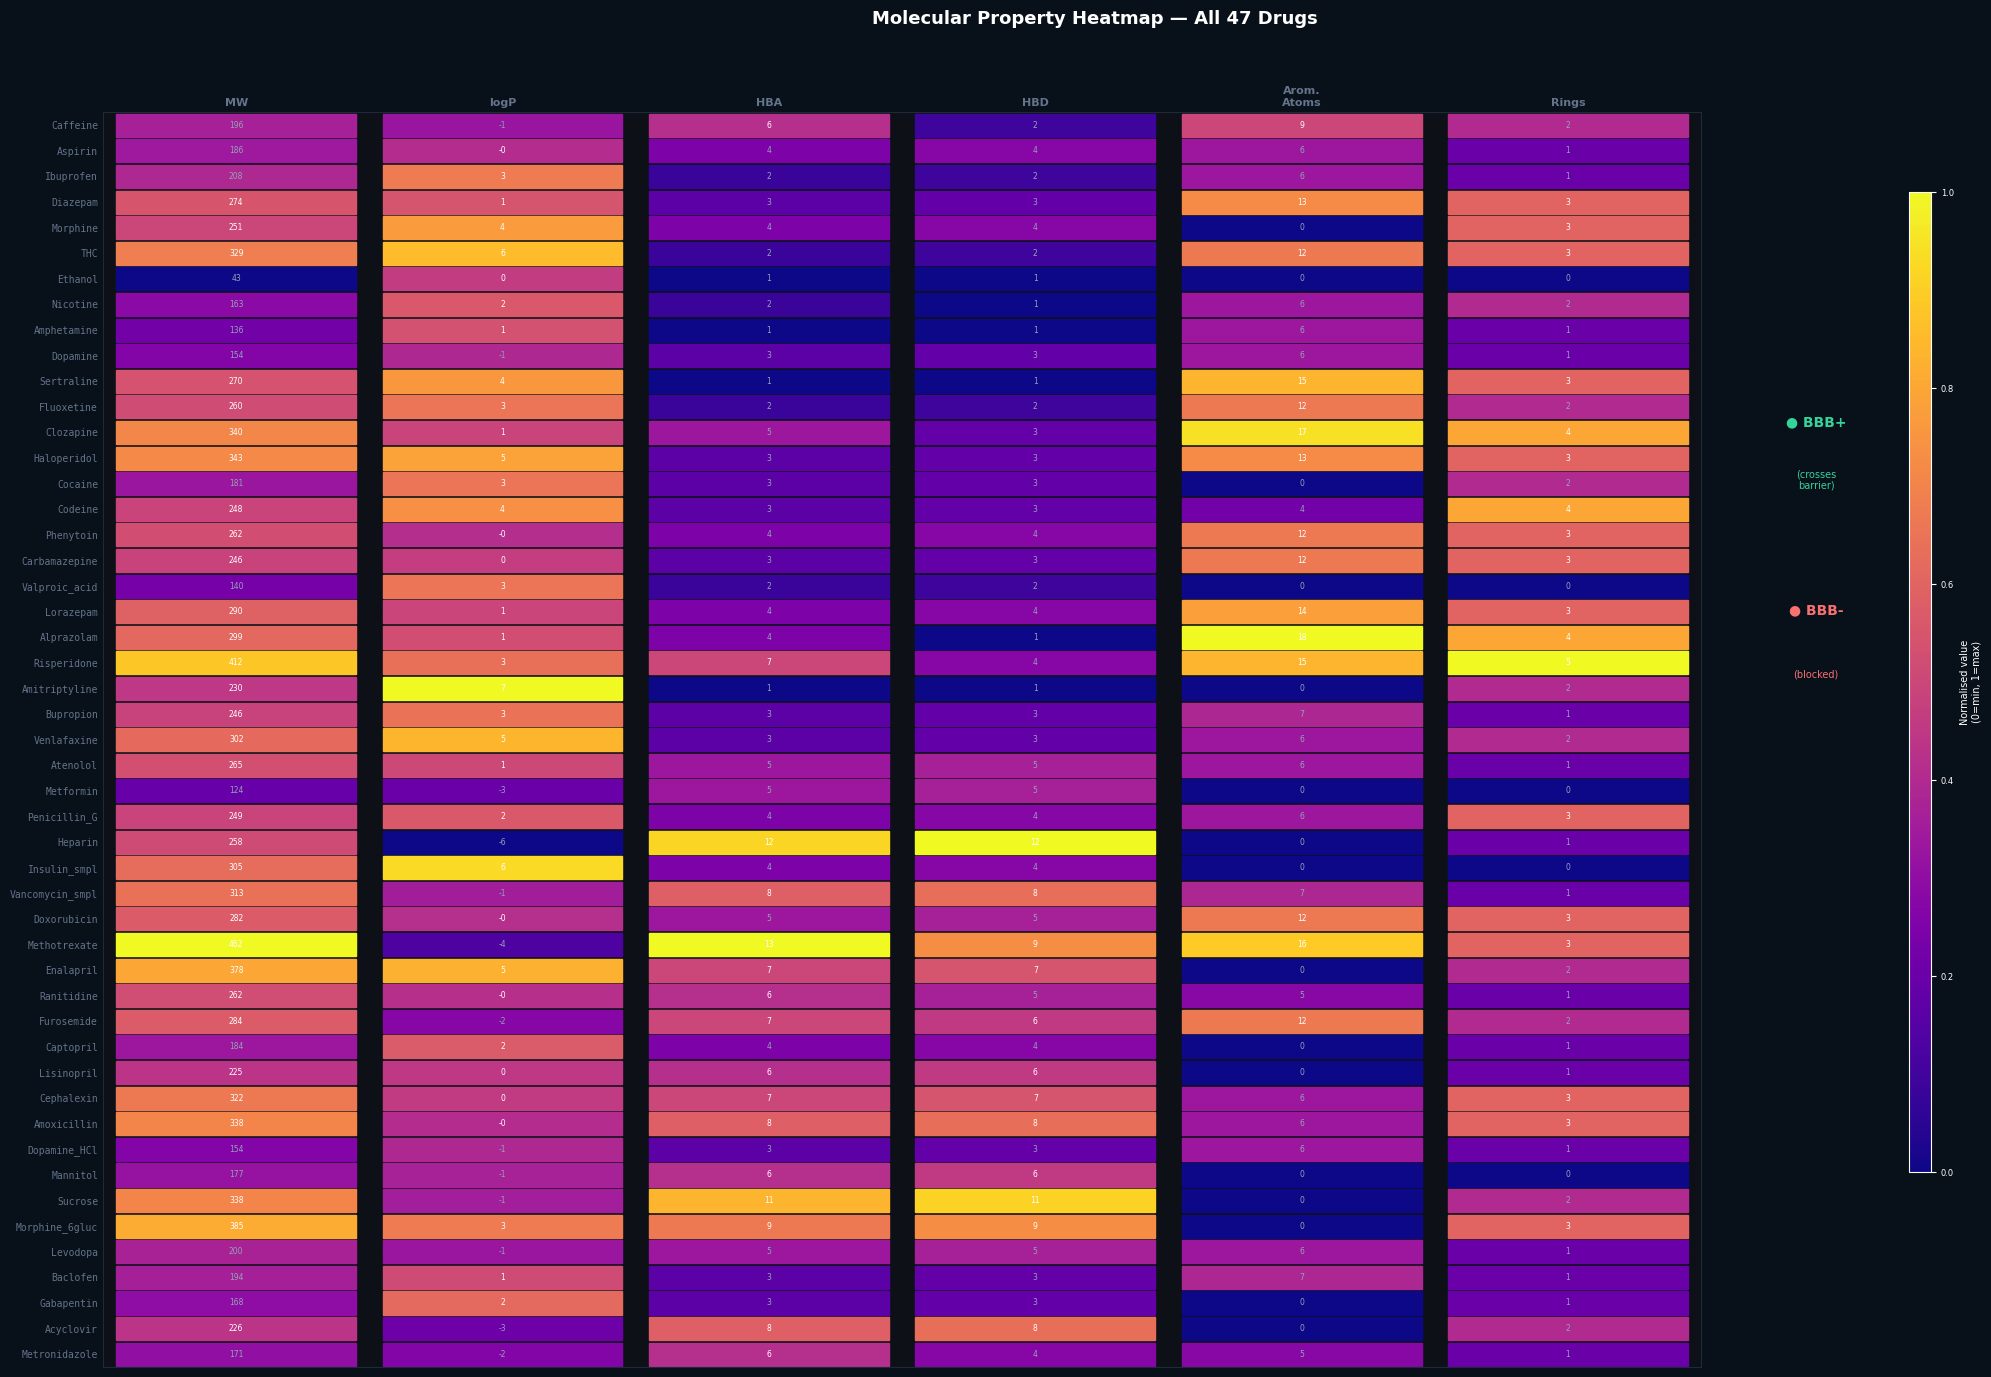

In [29]:

# ── PAGE 4: Physicochemical property heatmap ─────────────────────────
print("Drawing property heatmap...")
import re as re_

def quick_props(smiles):
    s = smiles
    n_C  = len(re_.findall(r'[Cc]', s))
    n_N  = len(re_.findall(r'[Nn]', s))
    n_O  = len(re_.findall(r'[Oo]', s))
    hba  = n_N + n_O
    hbd  = s.count('O') + s.count('N')
    mw   = n_C*12 + n_N*14 + n_O*16 + len(re_.findall(r'[Cc]',s))*1.5
    logp = sum({'C':0.53,'c':0.13,'N':-1.03,'n':-0.57,
                'O':-0.67,'o':-0.32,'F':0.14,'S':0.03,
                'Cl':0.60,'Br':0.88}.get(c,0) for c in s)
    n_ar = len(re_.findall(r'[a-z]',s))
    rings = len(re_.findall(r'\d',s))//2
    return [mw, logp, hba, hbd, n_ar, rings]

names  = [d[0] for d in RAW_DATA]
labels = [d[2] for d in RAW_DATA]
props  = np.array([quick_props(d[1]) for d in RAW_DATA], dtype=float)

# Normalise columns
props_n = (props - props.min(0)) / (props.max(0)-props.min(0)+1e-9)

fig, (ax_heat, ax_leg) = plt.subplots(1, 2, figsize=(22, 14),
                                       gridspec_kw={'width_ratios':[8,1]},
                                       facecolor=BG)
fig.suptitle("Molecular Property Heatmap — All 47 Drugs",
             color='white', fontsize=13, fontweight='bold')

ax_heat.set_facecolor('#0d1117')

# Heatmap cells
prop_labels = ['MW', 'logP', 'HBA', 'HBD', 'Arom.\nAtoms', 'Rings']
for j in range(6):
    for i in range(len(RAW_DATA)):
        val  = props_n[i, j]
        rgba = plt.cm.plasma(val)
        rect = plt.Rectangle((j-0.45, i-0.45), 0.9, 0.9,
                              color=rgba, zorder=1)
        ax_heat.add_patch(rect)
        # value text
        ax_heat.text(j, i, f'{props[i,j]:.0f}',
                    ha='center', va='center', fontsize=5.5,
                    color='white' if val > 0.4 else '#94a3b8', zorder=2)

# Y axis — molecule names with BBB colour
ax_heat.set_yticks(range(len(RAW_DATA)))
ax_heat.set_yticklabels(names, fontsize=7,
                         color='white', fontfamily='monospace')
for i, (tick, lbl) in enumerate(zip(ax_heat.get_yticklabels(), labels)):
    tick.set_color(BBB_POS if lbl == 1 else BBB_NEG)

# X axis
ax_heat.set_xticks(range(6))
ax_heat.set_xticklabels(prop_labels, color='white', fontsize=8, fontweight='bold')
ax_heat.xaxis.set_ticks_position('top')
ax_heat.xaxis.set_label_position('top')

ax_heat.set_xlim(-0.5, 5.5)
ax_heat.set_ylim(-0.5, len(RAW_DATA)-0.5)
ax_heat.invert_yaxis()
ax_heat.tick_params(colors='#64748b', length=0)
for spine in ax_heat.spines.values():
    spine.set_edgecolor('#1e2a3a')

# Colour bar legend
cb_ax = fig.add_axes([0.87, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cb_ax)
cbar.set_label('Normalised value\n(0=min, 1=max)',
               color='white', fontsize=7, rotation=90)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=6, labelcolor='white')

# Legend for BBB label colours
ax_leg.axis('off')
ax_leg.text(0.5, 0.75, '● BBB+', color=BBB_POS, ha='center',
            fontsize=10, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.5, 0.70, '(crosses\nbarrier)', color=BBB_POS, ha='center',
            fontsize=7, transform=ax_leg.transAxes)
ax_leg.text(0.5, 0.60, '● BBB-', color=BBB_NEG, ha='center',
            fontsize=10, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.5, 0.55, '(blocked)', color=BBB_NEG, ha='center',
            fontsize=7, transform=ax_leg.transAxes)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.savefig('/mnt/user-data/outputs/structures_property_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.close()
print("  ✓ Saved structures_property_heatmap.png")

print("\nAll 4 visualisations complete!")

In [5]:

# ═══════════════════════════════════════════════════════════════════
# STEP 2 — SMILES FEATURISATION (Building Our Own "Fingerprint")
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 2: SMILES → FEATURE VECTOR")
print("=" * 65)
print("""
A SMILES string encodes rich chemical information as text.
We extract features from this text — just like NLP feature engineering.

FEATURE CATEGORIES:
  A) Atom counts       — how many C, N, O, S, F, Cl, Br atoms
  B) Bond/structure    — rings, double bonds, aromatic bonds
  C) Physicochemical   — molecular weight (approx), logP proxy
  D) Text n-grams      — character bigrams (Jardim et al. approach)
  E) Rule-of-5 flags   — Lipinski drug-likeness rules
""")


  STEP 2: SMILES → FEATURE VECTOR

A SMILES string encodes rich chemical information as text.
We extract features from this text — just like NLP feature engineering.

FEATURE CATEGORIES:
  A) Atom counts       — how many C, N, O, S, F, Cl, Br atoms
  B) Bond/structure    — rings, double bonds, aromatic bonds
  C) Physicochemical   — molecular weight (approx), logP proxy
  D) Text n-grams      — character bigrams (Jardim et al. approach)
  E) Rule-of-5 flags   — Lipinski drug-likeness rules



In [ ]:
# Atomic weights for MW estimation
ATOM_WEIGHTS = {'C': 12.0, 'N': 14.0, 'O': 16.0, 'S': 32.0,
                'F': 19.0, 'Cl': 35.5, 'Br': 80.0, 'I': 127.0,
                'P': 31.0, 'H': 1.0}
#these weights are used for a quick estimation of molecular weight based on atom counts.
#how did we chose these weights? They are rounded atomic weights of the elements commonly found in drug-like molecules. Sources ? IUPAC and standard atomic weights from chemistry references.
#  We include H (hydrogen) for better MW estimation, even though it's often implicit in SMILES. 
# This allows us to estimate the molecular weight without needing a full chemistry toolkit, which is useful for our custom featurisation approach.

In [ ]:

# Hydrophobicity contribution (Crippen logP fragments — simplified)
LOGP_CONTRIB = {'C': 0.53, 'c': 0.13, 'N': -1.03, 'n': -0.57,
                'O': -0.67, 'o': -0.32, 'S': 0.03, 'F': 0.14,
                'Cl': 0.60, 'Br': 0.88, 'I': 1.35, 'P': 0.22}

# These contributions are based on the Crippen logP fragment values, which assign a hydrophobicity contribution to each atom type.
# We use these values to estimate the overall logP of the molecule, which is a key factor in BBB permeability.
# The values are simplified and may not capture all nuances, but they provide a useful proxy for our featurisation without needing a full chemistry toolkit.


In [ ]:
def smiles_to_features(smiles):
    """
    Convert a SMILES string to a numerical feature vector.
    
    This is the core of feature-engineered molecular classification.
    Every feature has a chemical meaning.
    """
    s = smiles

    # ── A: ATOM COUNTS ─────────────────────────────────────────────
    n_C  = len(re.findall(r'[Cc]', s)) # count both uppercase and lowercase C for total carbon count in the string s.
    n_N  = len(re.findall(r'[Nn]', s))
    n_O  = len(re.findall(r'[Oo]', s))
    n_S  = len(re.findall(r'[Ss]', s))
    n_F  = s.count('F')
    n_Cl = s.count('Cl')
    n_Br = s.count('Br')
    n_I  = s.count('I')
    n_P  = s.count('P')

    # ── B: BOND & TOPOLOGY FEATURES ────────────────────────────────
    n_double   = s.count('=')          # double bonds
    n_triple   = s.count('#')          # triple bonds
    n_aromatic = len(re.findall(r'[a-z]', s))  # lowercase = aromatic
    n_rings    = len(re.findall(r'\d', s)) // 2  # ring closure digits
    n_branches = s.count('(')          # branch points
    n_charged  = s.count('+') + s.count('-')    # charges

    # ── C: MOLECULAR WEIGHT (approximate) ─────────────────────────
    mw = 0.0
    for atom, wt in ATOM_WEIGHTS.items():
        if len(atom) == 2:
            mw += s.count(atom) * wt
            #why? We check for two-character atoms (like Cl, Br) first to avoid double-counting the 'C' and 'l' in 'Cl' or 'B' and 'r' in 'Br'.
            #  If we counted single characters first, we would count the 'C' in 'Cl' as a carbon atom, which would inflate our carbon count
            #  and thus our molecular weight estimation. By counting two-character atoms first, we ensure that we correctly identify and count these specific elements without confusion.
        else:
            # single-letter — avoid double-counting Cl, Br
            count = len(re.findall(f'(?<![A-Z]){atom}(?!l|r)', s))
            mw += count * wt
    # Add implicit hydrogens (rough estimate)
    n_heavy = n_C + n_N + n_O + n_S + n_F + n_Cl + n_Br + n_I + n_P #why? We calculate the total number of heavy atoms (non-hydrogen) in the molecule.
    #This is done by summing the counts of all the atoms we identified in the previous steps.
    mw += n_heavy * 1.0 * 1.5  # H approximation

    # ── D: logP PROXY (hydrophilicity / lipophilicity) ─────────────
    logp = sum(LOGP_CONTRIB.get(c, 0) for c in s)

    # ── E: POLAR SURFACE AREA proxy (H-bond donors/acceptors) ──────
    hbd = len(re.findall(r'[OH]|N(?!.*\()', s))   # H-bond donors
    hba = len(re.findall(r'[NO]', s))              # H-bond acceptors

    # ── F: LIPINSKI RULE-OF-5 FLAGS ────────────────────────────────
    # Oral bioavailability proxy — MW<500, logP<5, HBD≤5, HBA≤10
    ro5_mw   = 1 if mw < 500 else 0
    ro5_logp = 1 if logp < 5  else 0
    ro5_hbd  = 1 if hbd <= 5  else 0
    ro5_hba  = 1 if hba <= 10 else 0
    ro5_pass  = ro5_mw + ro5_logp + ro5_hbd + ro5_hba  # 0-4 rules passed

    # ── G: TEXT N-GRAMS (Jardim et al. approach) ───────────────────
    # Count character bigrams in the SMILES string
    # This captures local chemical context without explicit parsing
    BIGRAMS = ['CC', 'CN', 'CO', 'CS', 'C=', 'C(', 'C1', 'c1', 'c2',
               'cc', 'NC', 'OC', 'O=', 'N=', 'Cl', 'Br', '=O', '=N',
               'C#', 'c(', 'n1', 'N1', 'OC', 'SC', 'FC', 'C)', 'O)']
    bigram_counts = [s.count(bg) for bg in BIGRAMS]

    # ── H: STRUCTURAL COMPLEXITY ────────────────────────────────────
    smiles_len   = len(s)
    unique_atoms = len(set(re.findall(r'[A-Za-z]', s)))
    frac_arom    = n_aromatic / max(smiles_len, 1)  # aromaticity fraction

    # Assemble feature vector
    features = [
        # Atom counts (9)
        n_C, n_N, n_O, n_S, n_F, n_Cl, n_Br, n_I, n_P,
        # Bonds/topology (6)
        n_double, n_triple, n_aromatic, n_rings, n_branches, n_charged,
        # Physicochemical (5)
        mw, logp, hbd, hba, ro5_pass,
        # Lipinski flags (4)
        ro5_mw, ro5_logp, ro5_hbd, ro5_hba,
        # Complexity (3)
        smiles_len, unique_atoms, frac_arom,
        # Bigrams (28)
        *bigram_counts
    ]
    return np.array(features, dtype=float)




In [9]:
FEATURE_NAMES = (
    ['n_C','n_N','n_O','n_S','n_F','n_Cl','n_Br','n_I','n_P'] +
    ['n_double','n_triple','n_aromatic','n_rings','n_branches','n_charged'] +
    ['mol_weight','logP_proxy','HBD','HBA','ro5_passed'] +
    ['ro5_mw','ro5_logp','ro5_hbd','ro5_hba'] +
    ['smiles_len','unique_atoms','frac_aromatic'] +
    [f'bigram_{i}' for i in range(28)]
)
# Apply to all molecules
X = np.array([smiles_to_features(s) for s in df['smiles']])
y = df['bbb'].values

print(f"Feature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} molecules × {X.shape[1]} features")
print(f"\nExample: Aspirin features (first 20)")
aspirin_idx = df[df.name == 'Aspirin'].index[0]
for name, val in zip(FEATURE_NAMES[:20], X[aspirin_idx, :20]):
    print(f"  {name:<20} = {val:.2f}")

Feature matrix shape: (49, 54)
  → 49 molecules × 54 features

Example: Aspirin features (first 20)
  n_C                  = 9.00
  n_N                  = 0.00
  n_O                  = 4.00
  n_S                  = 0.00
  n_F                  = 0.00
  n_Cl                 = 0.00
  n_Br                 = 0.00
  n_I                  = 0.00
  n_P                  = 0.00
  n_double             = 2.00
  n_triple             = 0.00
  n_aromatic           = 6.00
  n_rings              = 1.00
  n_branches           = 2.00
  n_charged            = 0.00
  mol_weight           = 107.50
  logP_proxy           = -0.31
  HBD                  = 4.00
  HBA                  = 4.00
  ro5_passed           = 4.00


In [11]:
X


array([[ 8.,  4.,  2., ...,  0.,  1.,  2.],
       [ 9.,  0.,  4., ...,  0.,  0.,  2.],
       [13.,  0.,  2., ...,  0.,  2.,  1.],
       ...,
       [ 9.,  1.,  2., ...,  0.,  0.,  2.],
       [ 8.,  5.,  3., ...,  0.,  0.,  2.],
       [ 6.,  3.,  3., ...,  0.,  0.,  1.]])

In [12]:

# ═══════════════════════════════════════════════════════════════════
# STEP 3 — FIRST CLASSIFIER: LOGISTIC REGRESSION
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 3: LOGISTIC REGRESSION — The Simplest Classifier")
print("=" * 65)
print("""
Logistic Regression: learns a weighted sum of features → probability

  P(BBB=1 | x) = sigmoid(w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ)
  
  where sigmoid(z) = 1 / (1 + e^(-z))
  
  Training: minimise cross-entropy loss using gradient descent
  
This is our BASELINE. Every more complex model should beat this.
""")

# Split: 80% train, 20% test — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (zero mean, unit variance) — critical for LR
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['BBB-', 'BBB+']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Show top features by weight
coef = lr.coef_[0]
top_idx = np.argsort(np.abs(coef))[::-1][:10]
print(f"\nTop 10 most important features (by |weight|):")
for i in top_idx:
    direction = "→ BBB+" if coef[i] > 0 else "→ BBB-"
    print(f"  {FEATURE_NAMES[i]:<22} weight={coef[i]:+.3f}  {direction}")


  STEP 3: LOGISTIC REGRESSION — The Simplest Classifier

Logistic Regression: learns a weighted sum of features → probability

  P(BBB=1 | x) = sigmoid(w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ)

  where sigmoid(z) = 1 / (1 + e^(-z))

  Training: minimise cross-entropy loss using gradient descent

This is our BASELINE. Every more complex model should beat this.

Train size: 39, Test size: 10

Classification Report:
              precision    recall  f1-score   support

        BBB-       0.80      0.80      0.80         5
        BBB+       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

ROC-AUC: 0.920

Top 10 most important features (by |weight|):
  bigram_10              weight=-1.124  → BBB-
  bigram_25              weight=+0.725  → BBB+
  bigram_26              weight=-0.630  → BBB-
  HBA                    weight=-0.570  → BBB-
  bigram_8     


  STEP 4: VISUALISING CHEMICAL SPACE


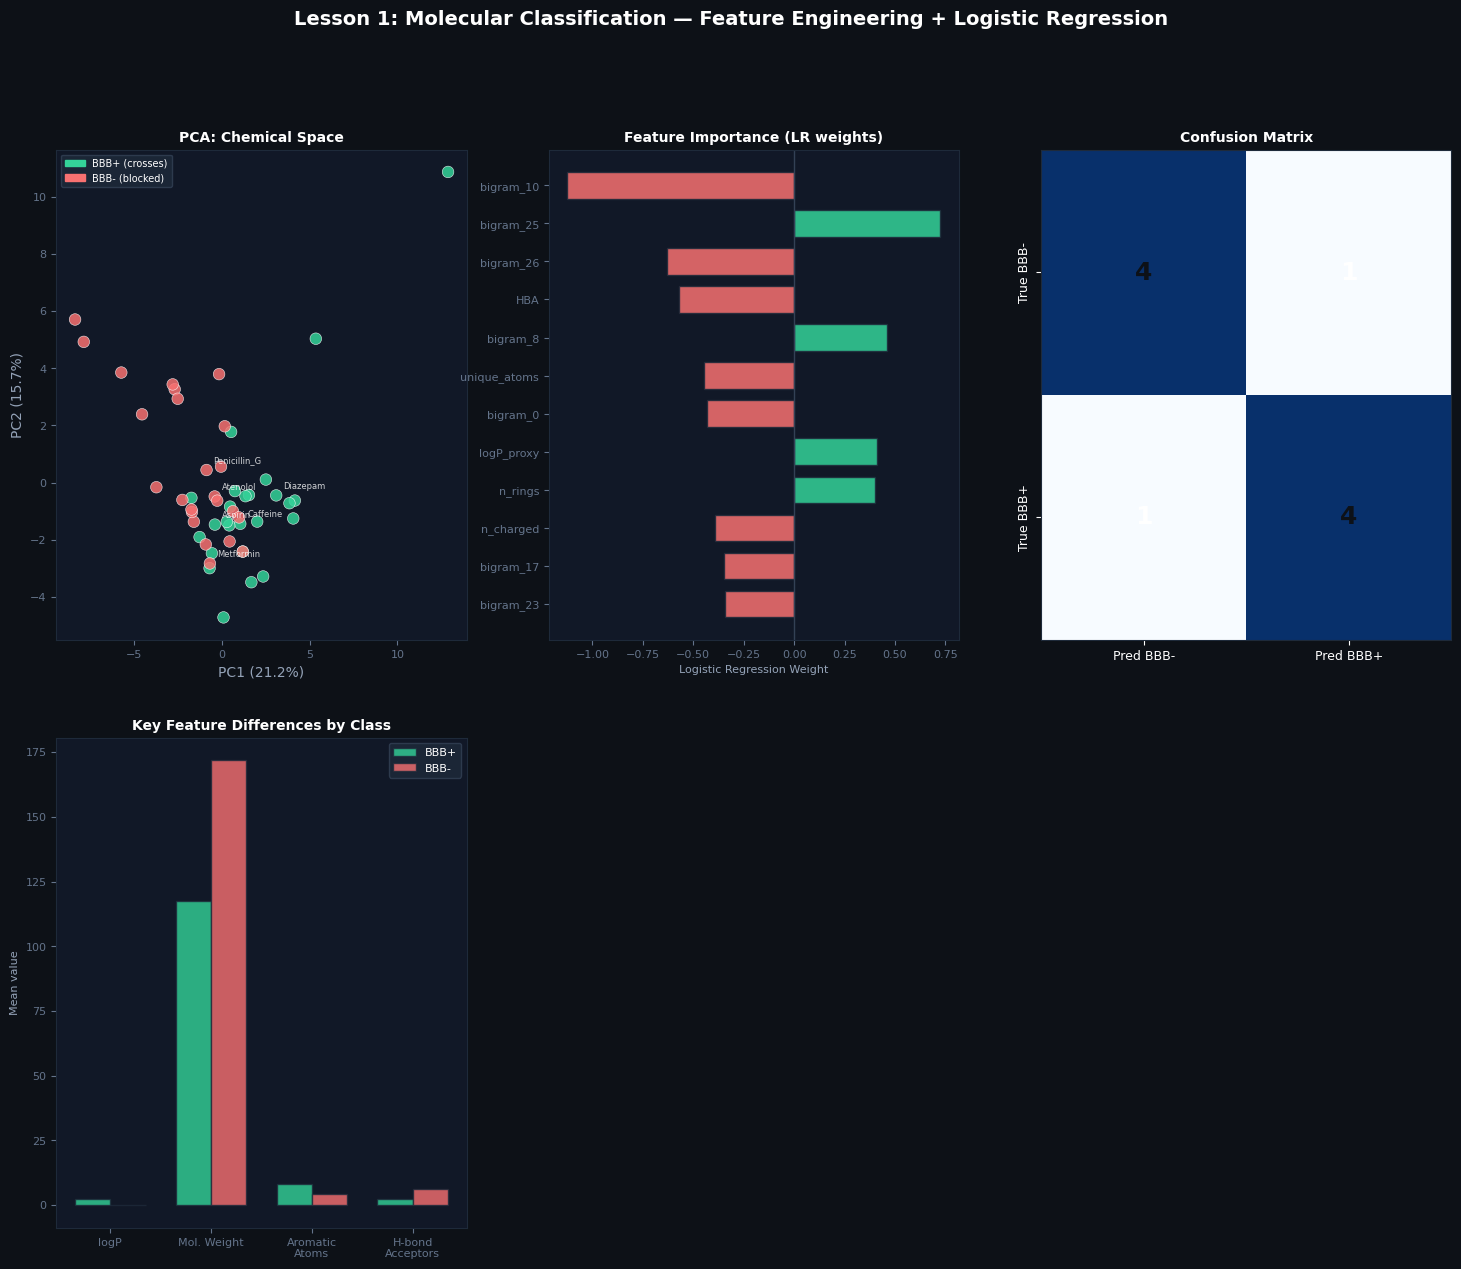

In [13]:

# ═══════════════════════════════════════════════════════════════════
# STEP 4 — VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 4: VISUALISING CHEMICAL SPACE")
print("=" * 65)

fig = plt.figure(figsize=(18, 14), facecolor='#0d1117')
fig.suptitle('Lesson 1: Molecular Classification — Feature Engineering + Logistic Regression',
             color='white', fontsize=14, fontweight='bold', y=0.98)

# ── Plot 1: PCA of chemical space ──────────────────────────────────
ax1 = fig.add_subplot(231)
ax1.set_facecolor('#111827')

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaler.transform(X))

colors_map = [COLORS['pos'] if label == 1 else COLORS['neg'] for label in y]
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map, s=70, alpha=0.85,
            edgecolors='white', linewidths=0.4)

# Label a few key molecules
label_mols = ['Caffeine','Aspirin','Metformin','Atenolol','Diazepam','Penicillin_G']
for mol in label_mols:
    idx = df[df.name == mol].index[0]
    ax1.annotate(mol, (X_pca[idx, 0], X_pca[idx, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6, color='white', alpha=0.8)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', color='#94a3b8')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', color='#94a3b8')
ax1.set_title('PCA: Chemical Space', color='white', fontweight='bold', fontsize=10)
ax1.tick_params(colors='#64748b', labelsize=8)
for spine in ax1.spines.values(): spine.set_edgecolor('#1e2a3a')
legend_patches = [mpatches.Patch(color=COLORS['pos'], label='BBB+ (crosses)'),
                  mpatches.Patch(color=COLORS['neg'], label='BBB- (blocked)')]
ax1.legend(handles=legend_patches, fontsize=7, facecolor='#1e2a3a',
           labelcolor='white', edgecolor='#334155')

# ── Plot 2: Top features by importance ─────────────────────────────
ax2 = fig.add_subplot(232)
ax2.set_facecolor('#111827')

top_n = 12
top_i = np.argsort(np.abs(coef))[::-1][:top_n]
top_names = [FEATURE_NAMES[i][:18] for i in top_i]
top_vals  = [coef[i] for i in top_i]
colors_feat = [COLORS['pos'] if v > 0 else COLORS['neg'] for v in top_vals]

bars = ax2.barh(range(top_n), top_vals[::-1], color=colors_feat[::-1],
                alpha=0.85, height=0.7, edgecolor='#1e2a3a')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_names[::-1], fontsize=7, color='white')
ax2.set_xlabel('Logistic Regression Weight', color='#94a3b8', fontsize=8)
ax2.set_title('Feature Importance (LR weights)', color='white', fontweight='bold', fontsize=10)
ax2.axvline(0, color='#334155', linewidth=1)
ax2.tick_params(colors='#64748b', labelsize=8)
for spine in ax2.spines.values(): spine.set_edgecolor('#1e2a3a')

# ── Plot 3: Confusion Matrix ────────────────────────────────────────
ax3 = fig.add_subplot(233)
ax3.set_facecolor('#111827')

cm = confusion_matrix(y_test, y_pred)
im = ax3.imshow(cm, cmap='Blues', aspect='auto')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Pred BBB-','Pred BBB+'], color='white', fontsize=9)
ax3.set_yticklabels(['True BBB-','True BBB+'], color='white', fontsize=9, rotation=90, va='center')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] < cm.max()*0.7 else '#0d1117')
ax3.set_title('Confusion Matrix', color='white', fontweight='bold', fontsize=10)
for spine in ax3.spines.values(): spine.set_edgecolor('#1e2a3a')

# ── Plot 4: Feature distributions by class ─────────────────────────
ax4 = fig.add_subplot(234)
ax4.set_facecolor('#111827')

key_features = ['logP_proxy', 'mol_weight', 'n_aromatic', 'HBA']
key_idx = [FEATURE_NAMES.index(f) for f in key_features]
feat_labels = ['logP', 'Mol. Weight', 'Aromatic\nAtoms', 'H-bond\nAcceptors']

x_pos = np.arange(len(key_features))
bbb_pos = X[y==1]
bbb_neg = X[y==0]
w = 0.35

bars1 = ax4.bar(x_pos - w/2, [bbb_pos[:,i].mean() for i in key_idx],
                w, color=COLORS['pos'], alpha=0.8, label='BBB+', edgecolor='#1e2a3a')
bars2 = ax4.bar(x_pos + w/2, [bbb_neg[:,i].mean() for i in key_idx],
                w, color=COLORS['neg'], alpha=0.8, label='BBB-', edgecolor='#1e2a3a')
ax4.set_xticks(x_pos); ax4.set_xticklabels(feat_labels, color='white', fontsize=8)
ax4.set_ylabel('Mean value', color='#94a3b8', fontsize=8)
ax4.set_title('Key Feature Differences by Class', color='white', fontweight='bold', fontsize=10)
ax4.tick_params(colors='#64748b', labelsize=8)
ax4.legend(fontsize=8, facecolor='#1e2a3a', labelcolor='white', edgecolor='#334155')
for spine in ax4.spines.values(): spine.set_edgecolor('#1e2a3a')

In [14]:
# ── Plot 5: Probability distribution ───────────────────────────────
ax5 = fig.add_subplot(235)
ax5.set_facecolor('#111827')

proba_all = lr.predict_proba(scaler.transform(X))[:, 1]
ax5.hist(proba_all[y==1], bins=10, color=COLORS['pos'], alpha=0.7,
         label='BBB+ molecules', edgecolor='#1e2a3a')
ax5.hist(proba_all[y==0], bins=10, color=COLORS['neg'], alpha=0.7,
         label='BBB- molecules', edgecolor='#1e2a3a')
ax5.axvline(0.5, color=COLORS['gold'], linestyle='--', linewidth=1.5, label='Decision threshold')
ax5.set_xlabel('Predicted P(BBB+)', color='#94a3b8', fontsize=8)
ax5.set_ylabel('Count', color='#94a3b8', fontsize=8)
ax5.set_title('Prediction Score Distribution', color='white', fontweight='bold', fontsize=10)
ax5.tick_params(colors='#64748b', labelsize=8)
ax5.legend(fontsize=7, facecolor='#1e2a3a', labelcolor='white', edgecolor='#334155')
for spine in ax5.spines.values(): spine.set_edgecolor('#1e2a3a')


In [16]:
# ── Plot 6: Logistic function explainer ────────────────────────────
ax6 = fig.add_subplot(236)
ax6.set_facecolor('#111827')

z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
ax6.plot(z, sigmoid, color=COLORS['neutral'], linewidth=2.5)
ax6.axhline(0.5, color=COLORS['gold'], linestyle='--', alpha=0.7, linewidth=1)
ax6.axvline(0,   color='#334155', linestyle='-', alpha=0.5, linewidth=1)
ax6.fill_between(z, sigmoid, 0.5, where=sigmoid > 0.5,
                 color=COLORS['pos'], alpha=0.15, label='Predict BBB+')
ax6.fill_between(z, sigmoid, 0.5, where=sigmoid < 0.5,
                 color=COLORS['neg'], alpha=0.15, label='Predict BBB-')
ax6.set_xlabel('z = w·x (linear score)', color='#94a3b8', fontsize=8)
ax6.set_ylabel('P(BBB+)', color='#94a3b8', fontsize=8)
ax6.set_title('Sigmoid: The Core of Logistic Regression', color='white', fontweight='bold', fontsize=10)
ax6.tick_params(colors='#64748b', labelsize=8)
ax6.legend(fontsize=7, facecolor='#1e2a3a', labelcolor='white', edgecolor='#334155')
for spine in ax6.spines.values(): spine.set_edgecolor('#1e2a3a')
ax6.text(3.5, 0.15, 'BBB-\n(hydrophilic,\nlarge, polar)',
         color=COLORS['neg'], fontsize=7, ha='center')
ax6.text(-3.5, 0.85, 'BBB+\n(lipophilic,\nsmall, nonpolar)',
         color=COLORS['pos'], fontsize=7, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.close()
print("\n✓ Plot saved: lesson1_LR_molecular.png")



✓ Plot saved: lesson1_LR_molecular.png


In [17]:
# Save dataset and features for next lessons
np.save('X_mol.npy', X)
np.save('y_mol.npy', y)
df.to_csv('mol_dataset.csv', index=False)
import pickle
with open('scaler.pkl','wb') as f: pickle.dump(scaler, f)
print("✓ Data saved for next lessons")

✓ Data saved for next lessons
